# Viscosity Pipeline Usage Example

This notebook shows how to run the reusable viscosity pipeline on:
'dynamic_analysis_full_run_custom_20260513_093259.csv'
Workflow covered:
1. Load dataset
2. Normalize x-axis by cell
3. Trim before-hit and after-contact zones
4. Fit Polynomial(2nd) and Hyperbola
5. Map known real viscosities (user input)
6. Extrapolate unknown viscosities
7. Plot fits and accuracy

In [5]:
from pathlib import Path
import sys

import pandas as pd

# Locate helper module robustly across common notebook working directories.
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / 'results' / 'Auto-runs',
    Path.cwd().parent,
]
helper_dir = next((d for d in candidate_dirs if (d / 'viscosity_pipeline_helper_hitpoint_trim.py').exists()), None)
if helper_dir is None:
    raise FileNotFoundError('Could not locate viscosity_pipeline_helper_hitpoint_trim.py')
if str(helper_dir) not in sys.path:
    sys.path.insert(0, str(helper_dir))

from viscosity_pipeline_helper_hitpoint_trim import run_viscosity_pipeline

In [6]:
# Dataset to analyze
csv_filename = 'dynamic_analysis_full_run_custom_20260513_093259.csv'
csv_candidates = [
    Path.cwd() / csv_filename,
    Path.cwd() / 'results' / 'Auto-runs' / csv_filename,
    helper_dir / csv_filename,
    helper_dir.parent / 'results' / 'Auto-runs' / csv_filename,
]
csv_path_obj = next((path for path in csv_candidates if path.exists()), None)
if csv_path_obj is None:
    raise FileNotFoundError(f'CSV file not found: {csv_filename}')
csv_path = str(csv_path_obj)

# USER INPUT: known calibration viscosities in cP.
# Keep only cells you trust for calibration. Unknown cells can be omitted.

#real_viscosity_map = {
#    1: 11860,
#    2: 11860,
#    3: 11860,
#    4: 11860,
#    5: 11860,
#    6: 11860,
#    7: 11860,
#    8: 11860,
#    9: 11860,
#    10: 11860,
#    11: 11860,
#    12: 11860,
#    13: 11860,
#    14: 11860,
#    15: 11860,
#    16: 11860,
#    17: 11860,
#    18: 11860
#}

real_viscosity_map = {
     1: 1000,
     2: 1154,
     3: 3347,
     4: 6611,
     5: 5865,
     6: 8930,
     7: 11860,
     8: 14590,
     9: 19000,
     10: 22730,
     11: 31870,
     12: 40850,
     13: 48520,
     14: 37020,
     15: 69080,
     16: 70730,
     17: 93270,
     18: 124800,
  }

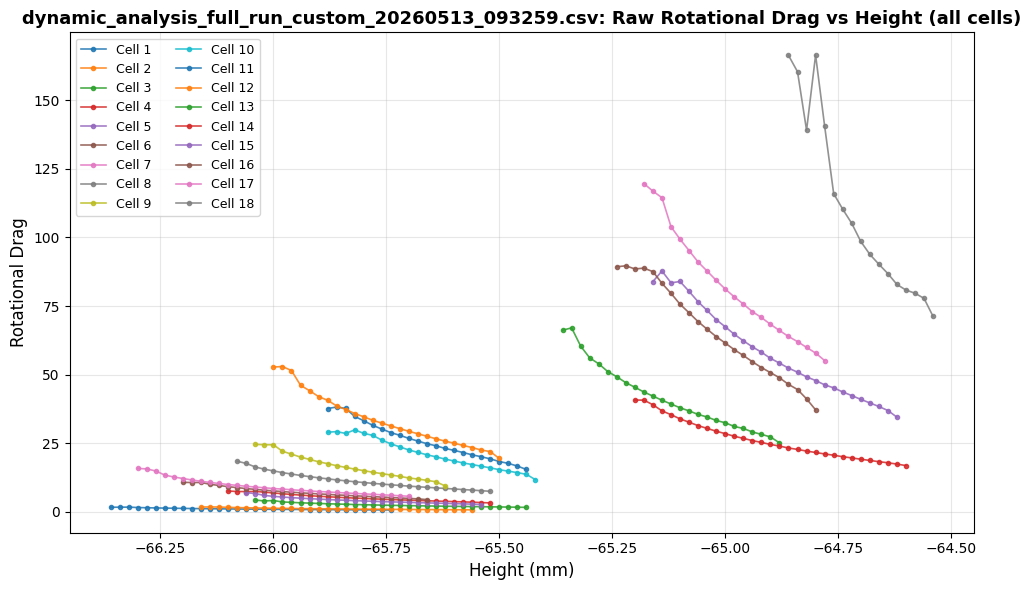

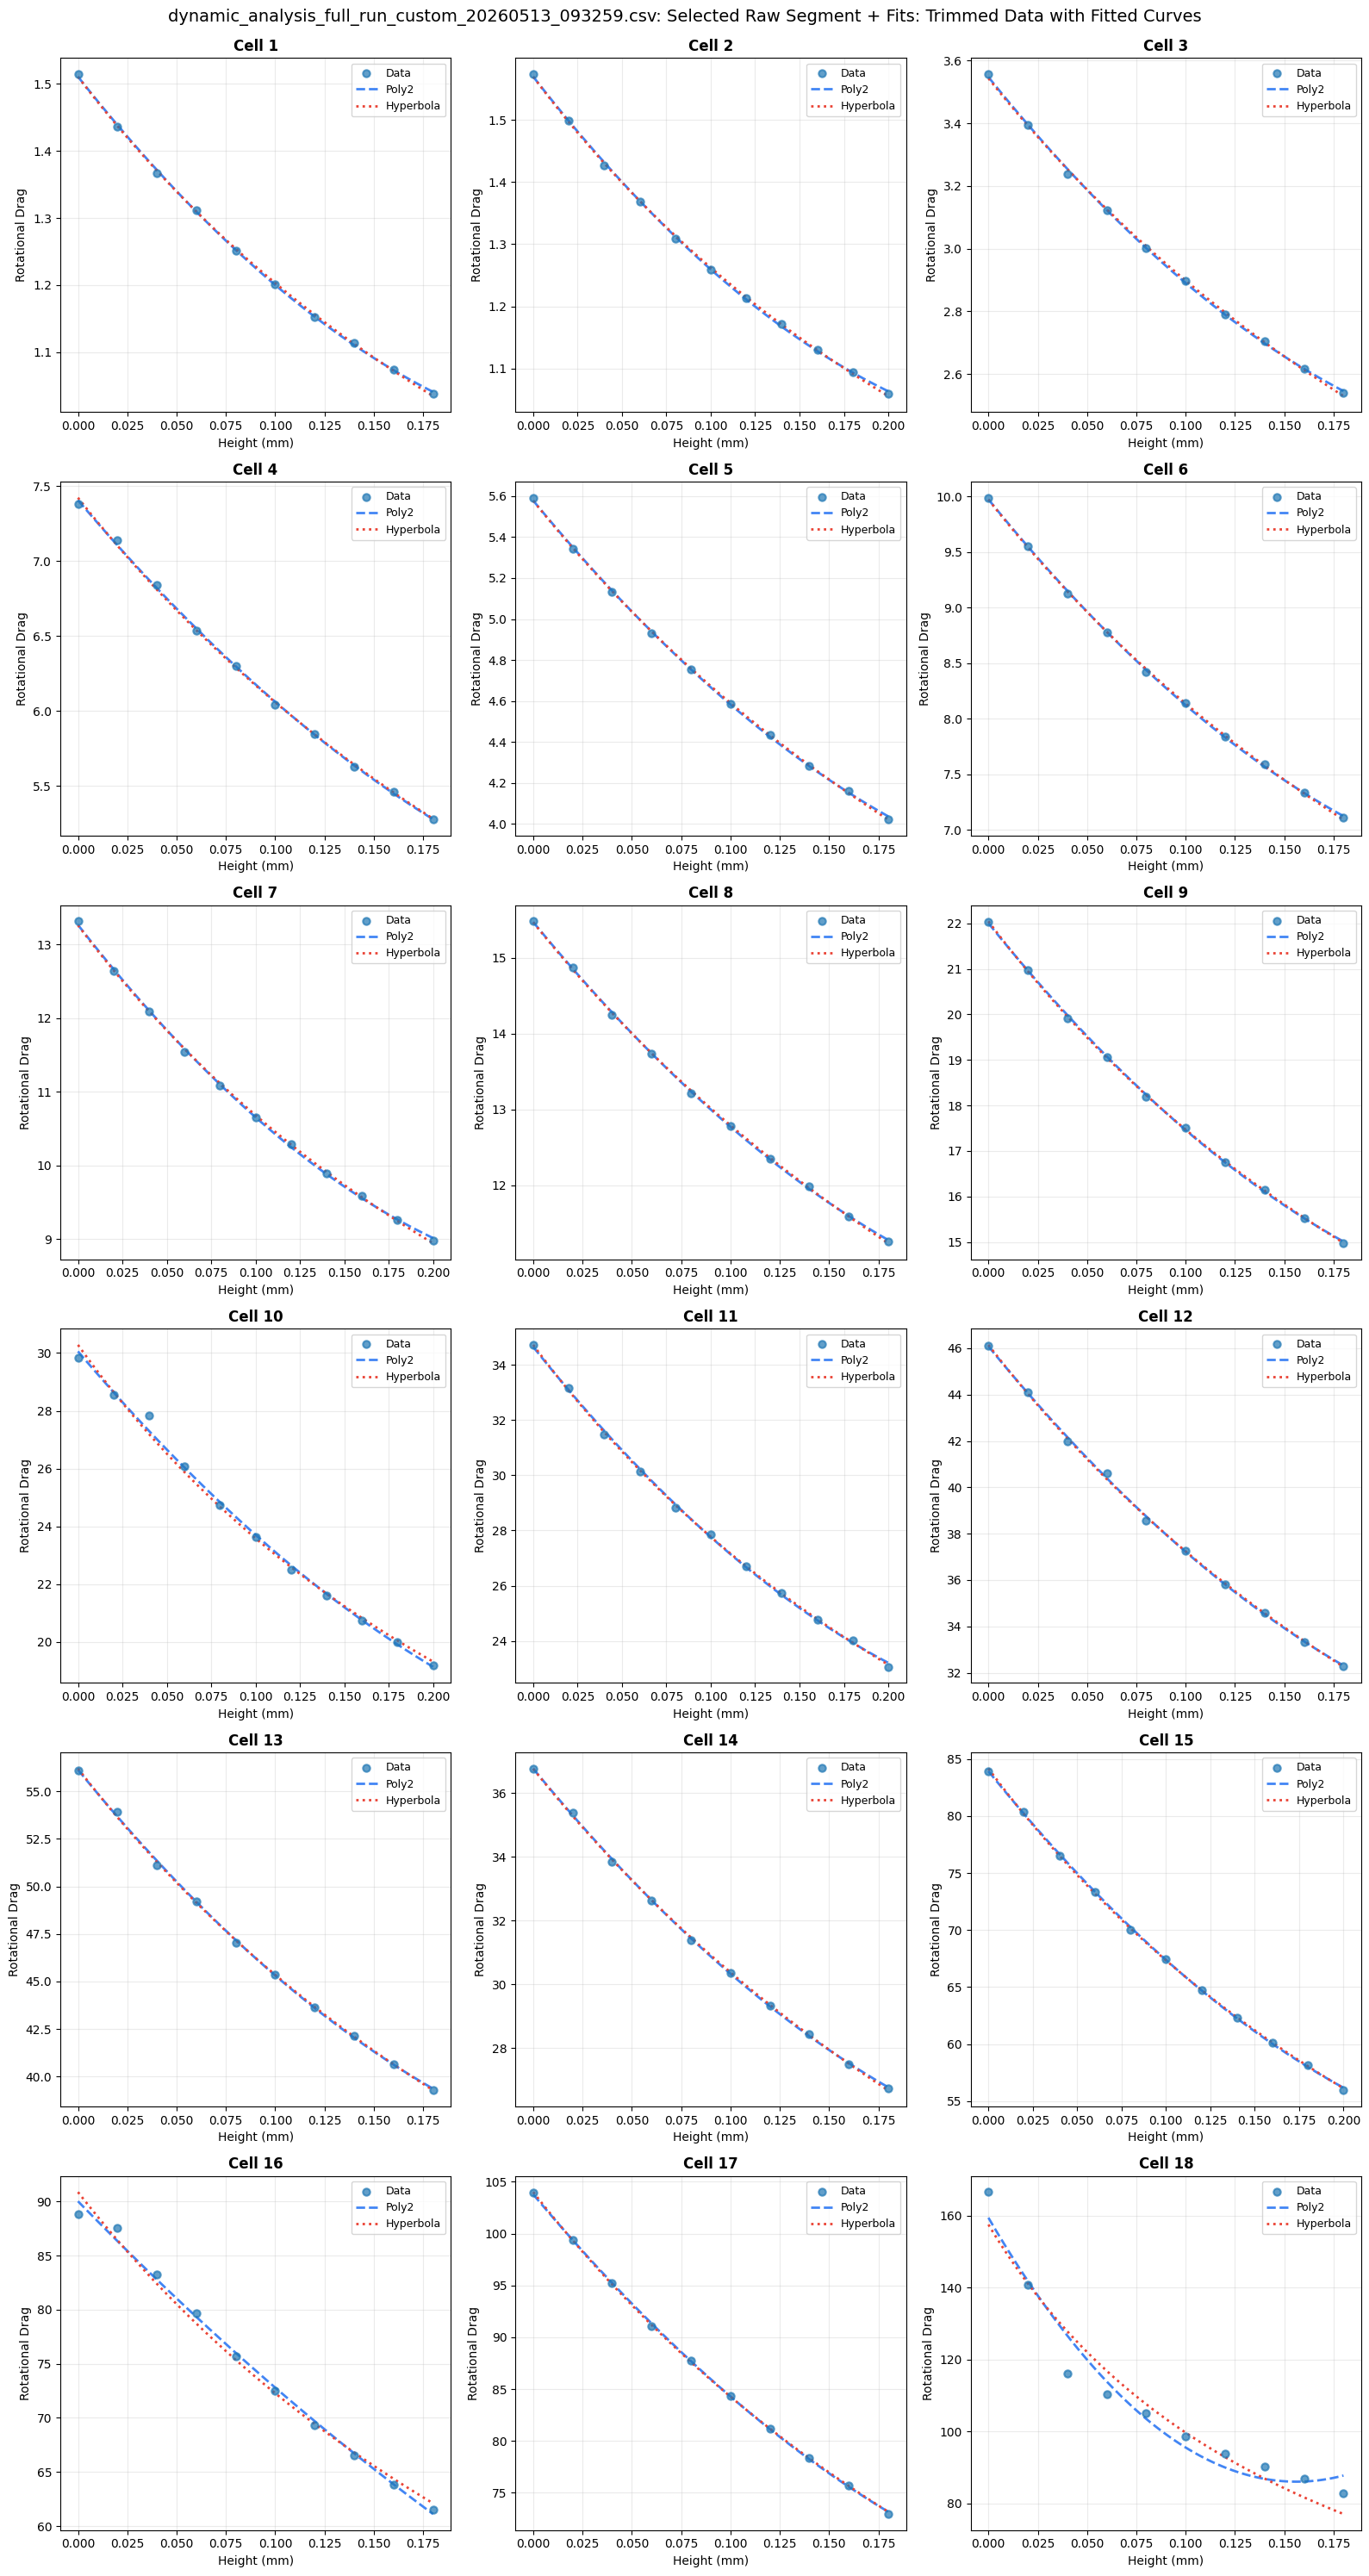

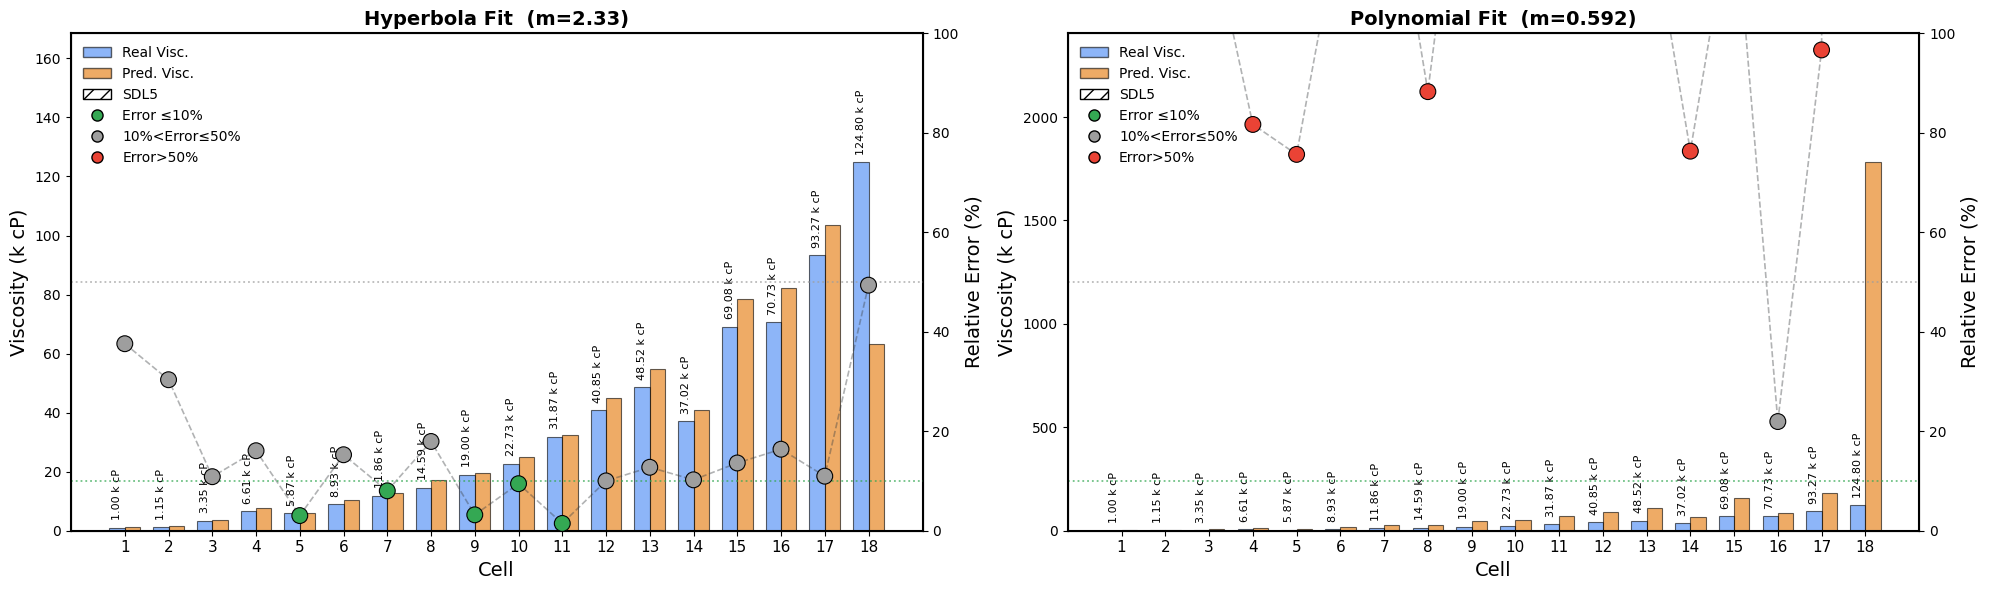

Learned scaling factors: {'poly': 0.592, 'hyperbola': 2.33}


In [7]:
pipeline_out = run_viscosity_pipeline(
    csv_path=csv_path,
    real_viscosity_map=real_viscosity_map,
    visualize=True,
)

print('Learned scaling factors:', pipeline_out['scales'])

In [8]:
pred_cols = [
    'cell',
    'a_poly2',
    'a_hyperbola',
    'real_viscosity',
    'predicted_visc_pol',
    'predicted_visc_hyp',
    'rel_error_pol',
    'rel_error_hyp',
    'is_calibration',
]

pred_df = pipeline_out['predictions'][pred_cols].sort_values('cell').reset_index(drop=True)
display(pred_df)

# Optional: save the predictions table
# pred_df.to_csv('viscosity_predictions_dynamic_analysis_L60kcP.csv', index=False)

,cell,a_poly2,a_hyperbola,real_viscosity,predicted_visc_pol,predicted_visc_hyp,rel_error_pol,rel_error_hyp,is_calibration
0,1,6.199337,0.590552,1000,3.670008,1.375985,267.000758,37.598503,True
1,2,5.704129,0.645638,1154,3.376844,1.504337,192.620818,30.358487,True
2,3,12.569479,1.592527,3347,7.441132,3.710587,122.322428,10.863078,True
3,4,20.288826,3.293604,6611,12.010985,7.674098,81.681816,16.080748,True
4,5,17.403144,2.593842,5865,10.302661,6.043651,75.663448,3.046050,True
5,6,33.685104,4.418044,8930,19.941582,10.294042,123.309985,15.274829,True
6,7,48.562564,5.498324,11860,28.749038,12.811094,142.403355,8.019343,True
7,8,46.401515,7.385364,14590,27.469697,17.207898,88.277567,17.943100,True
8,9,82.495691,8.415183,19000,48.837449,19.607376,157.039207,3.196717,True
9,10,88.869470,10.677798,22730,52.610726,24.879269,131.459420,9.455648,True
